## k‑Nearest Neighbors (K-NN)

Colab de referência: https://colab.research.google.com/drive/13kaBaoI_3tjaB3DsrlON6_K_rG_AkIwK

In [1]:
from sklearn import datasets # Biblioteca de datasets
vinho = datasets.load_wine() # Escolha do dataset de vinhos
print(vinho.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [2]:
print (vinho.feature_names) # Mostra os rótulos das características
print (vinho.target_names) # Mostra os rótulos das classes
print (vinho.data[0:5]) # Mostra as 5 primeiras amostras do dataset
print(vinho.target) # Mostra os identificadores das classes
print(vinho.data.shape) # Mostra o tamanho total do dataset

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 

## Agrupamento dos identificadores das classes com *List Comprehension*
Para entender a distribuição das classes no dataset, utilizamos a função `groupby` da biblioteca `itertools`. Esta função nos permite agrupar as amostras de acordo com suas classes e contar quantas amostras pertencem a cada classe. A técnica de *list comprehension* utilizada aqui é um método conciso e eficiente para criar listas em Python.

In [3]:
from itertools import groupby
[len(list(group)) for _, group in groupby(vinho.target)]

[59, 71, 48]

## Divisão do dataset em amostras treinamento e de teste
Uma prática comum em Machine Learning é dividir o dataset em conjuntos de treinamento e teste. O conjunto de treinamento é usado para treinar o modelo, enquanto o conjunto de teste é usado para avaliar seu desempenho em dados que não foram vistos durante o treinamento. Aqui, utilizamos a função `train_test_split` do `sklearn` para realizar essa divisão.

### Escolhendo a proporção dos dados
A proporção entre os conjuntos de treinamento e teste é geralmente escolhida com base no tamanho do dataset e na necessidade de obter um bom balanceamento entre o treinamento do modelo e a validação de sua performance. Uma divisão comum é 70% dos dados para treinamento e 30% para teste. Isso proporciona um conjunto de treinamento suficientemente grande para modelar bem os dados, enquanto mantém um conjunto de teste significativo para avaliação.

In [4]:
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(vinho.data, vinho.target, test_size=0.3)
print(y_treino) # Amostras selecionadas para treinamento
print(y_teste) # Amostras selecionadas para teste

[1 1 1 1 2 1 2 2 1 0 2 1 2 0 1 2 0 0 1 1 1 0 0 0 1 1 1 2 1 0 1 0 1 2 1 1 0
 1 0 1 1 2 2 0 1 1 2 0 2 0 1 1 2 0 2 2 0 0 1 2 1 2 1 1 2 0 1 1 1 2 0 2 0 1
 2 0 0 2 1 1 1 0 0 0 1 1 0 1 1 2 0 0 0 0 0 1 0 2 1 2 1 2 1 2 2 1 0 1 1 2 0
 2 0 1 0 0 1 2 1 2 2 2 1 1]
[2 0 0 0 0 2 1 1 1 2 2 1 1 0 0 0 0 1 2 1 0 1 2 2 1 0 1 0 0 0 2 1 0 1 1 0 2
 1 1 0 0 1 0 2 2 0 0 2 2 1 0 1 0 2]


### Treinamento e avaliação do modelo k-NN
Agora que os dados estão preparados, podemos treinar um modelo de classificação. Vamos usar o algoritmo k-Nearest Neighbors (k-NN), que é um dos mais simples e intuitivos em Machine Learning.

## Mas como funciona o k-NN?
O k-NN é um algoritmo de classificação baseado em instâncias. Ele opera sob o princípio de que uma amostra deve ser classificada da mesma forma que as amostras mais próximas a ela em um espaço de características. Para determinar a classe de uma nova amostra, o k-NN analisa os `k` exemplos mais próximos no conjunto de treinamento e atribui ao objeto desconhecido a classe que é mais comum entre esses vizinhos. A escolha de `k` é crítica e pode afetar significativamente o desempenho do modelo.

Um valor muito pequeno de `k` pode tornar o modelo sensível ao ruído, enquanto um valor muito grande pode diluir a influência dos vizinhos mais próximos além de tender para classes majoritárias em problemas com conjunto de dados desbalanceados.

### Treinamento do modelo com o método `fit`


In [5]:
from sklearn.neighbors import KNeighborsClassifier # Importa o classificador
knn = KNeighborsClassifier(n_neighbors=5) # Cria o modelo com k = 5
knn.fit(X_treino, y_treino) # Treinamento

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predição com o método `predict`

In [6]:
y_predito = knn.predict(X_teste) # Predição
print(y_predito) # Mostra o resultado da predição

[2 0 0 0 0 1 1 1 1 1 0 2 1 0 0 0 0 1 0 1 0 0 0 1 1 0 2 0 0 0 1 1 0 1 2 0 2
 1 1 0 0 2 0 1 2 0 0 2 1 1 2 1 0 2]


### Avaliação do modelo com o método `score`


In [7]:
acuracia = knn.score(X_teste, y_teste) # Calcula a acurácia da predição
acuracia = acuracia * 100
print(f" Acurácia: {acuracia:.2f}%") # Mostra a acurácia da predição

 Acurácia: 72.22%


## Validação cruzada
Para obter uma estimativa mais confiável do desempenho do modelo, utilizamos a validação cruzada. Na validação cruzada, o dataset é dividido em várias partes, ou 'folds', e o modelo é treinado e testado múltiplas vezes, cada vez utilizando uma parte diferente como conjunto de teste e as demais como conjunto de treinamento. Existem vários tipos de validação cruzada, cada um com suas vantagens e desvantagens.

### Tipos de validação cruzada
- **k-Fold Cross Validation**: O dataset é dividido em 'k' partes, e o modelo é treinado 'k' vezes, cada vez utilizando uma parte diferente como conjunto de teste. A vantagem é que todos os dados são eventualmente utilizados tanto para treinamento quanto para teste. A desvantagem é que pode ser computacionalmente caro.
- **Leave-One-Out Cross Validation (LOOCV)**: Cada amostra do dataset é utilizada uma vez como conjunto de teste, enquanto as outras amostras formam o conjunto de treinamento. Embora seja mais preciso, é ainda mais caro computacionalmente do que o k-Fold.
- **Stratified k-Fold**: Semelhante ao k-Fold, mas garante que a proporção de classes em cada *fold* seja representativa do dataset original, o que é especialmente útil em datasets desbalanceados.

### Validação cruzada com `cross_val_score`
A função `cross_val_score` facilita a realização da validação cruzada. Ela recebe como entradas o modelo (neste caso, um classificador k-NN), os dados (`vinho.data`), as classes (`vinho.target`) e o número de folds (`cv=5`). A função executa a validação cruzada e retorna uma lista com as acurácias obtidas em cada iteração. A média dessas acurácias pode ser utilizada como uma estimativa da performance geral do modelo.

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np
knn = KNeighborsClassifier(n_neighbors=3)
acuracias_vc = cross_val_score(knn, vinho.data, vinho.target, cv=5)
acuracias_vc = acuracias_vc * 100
print(acuracias_vc)
print(f"Média das acurácias: {np.mean(acuracias_vc):.2f}%")

[63.88888889 69.44444444 66.66666667 65.71428571 85.71428571]
Média das acurácias: 70.29%


### Avaliando diversos valores de `k`

No código abaixo, geramos um gráfico de linha representando os valores das acurácias do modelo k-NN com `k` variando entre 10 e 35, de 5 em 5, aplicando a validação cruzada.

k = 10 - Acurácia: 69.11%
k = 15 - Acurácia: 71.38%
k = 20 - Acurácia: 70.83%
k = 25 - Acurácia: 70.84%
k = 30 - Acurácia: 71.97%
k = 35 - Acurácia: 70.29%


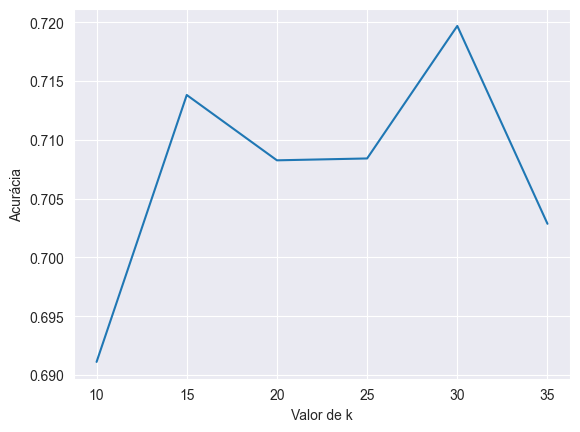

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista dos valores de 'k' para o k-NN
ks = [10, 15, 20, 25, 30, 35]

# Lista vazia para armazenar as acurácias médias
acuracias = []

# Loop para calcular a acurácia média para cada valor de 'k'
for indice, k in enumerate(ks):
    # Cria o classificador k-NN com o valor de 'k' atual
    knn = KNeighborsClassifier(n_neighbors=k)

    # Executa a validação cruzada 5-fold e armazena as acurácias obtidas
    acuracias_vc = cross_val_score(knn, vinho.data, vinho.target, cv=5)

    # Calcula a acurácia média das 5 dobras e adiciona à lista de acurácias
    acuracias.append(np.mean(acuracias_vc))

    print(f"k = {k} - Acurácia: {acuracias[indice]*100:.2f}%")

# Criar o gráfico de linha com os valores de 'k' no eixo x e as acurácias médias no eixo y
sns.lineplot(x=ks, y=acuracias)

# Adicionar as legendas dos eixos
plt.ylabel('Acurácia')
plt.xlabel('Valor de k')

# Mostrar o gráfico na tela
plt.show()